#### Dataset

In [2]:
# banknotes.csv
# https://mitu.co.in/dataset

#### Load necessary libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

#### Load the dataset

In [6]:
df = pd.read_csv('datasets/banknotes.csv')

In [7]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [8]:
df.shape

(1372, 5)

In [9]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


#### Separate the input and output variables

In [11]:
# input 
x = df.drop('Class', axis = 1)

# output 
y = df['Class']

In [12]:
y.value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [14]:
y = y.map({0:'Original',1:'Fake'})

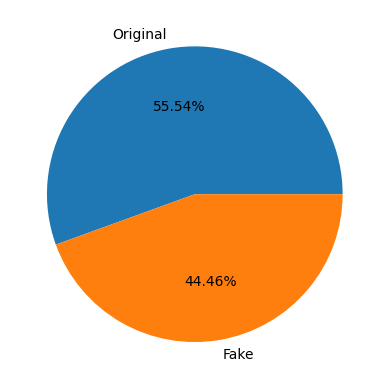

In [16]:
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%2.2f%%');

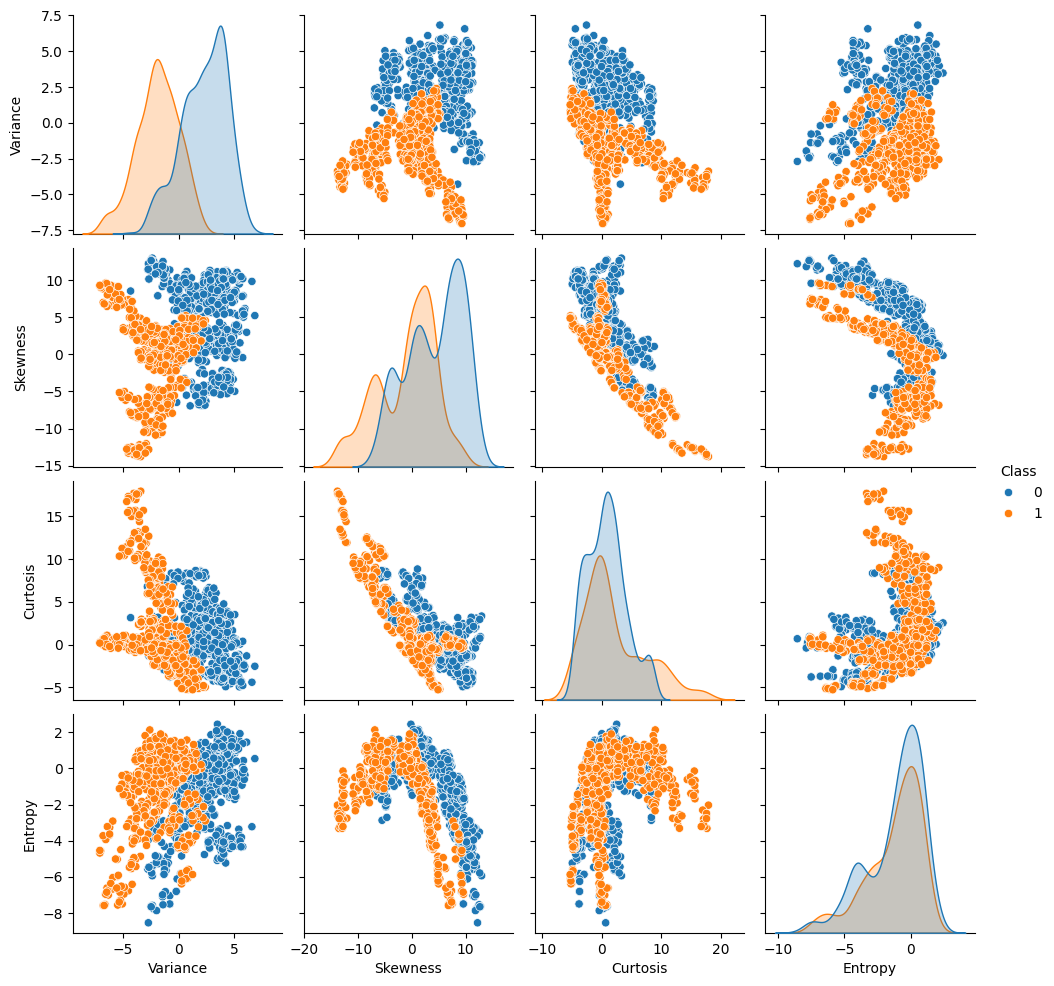

In [18]:
sns.pairplot(df, hue='Class');

#### Cross Validation

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [21]:
x_train.shape

(1029, 4)

In [22]:
x_test.shape

(343, 4)

#### Build the model

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt = DecisionTreeClassifier(random_state=0)

In [26]:
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=0)

#### Evaluate the classifier

In [28]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [29]:
y_pred = dt.predict(x_test)

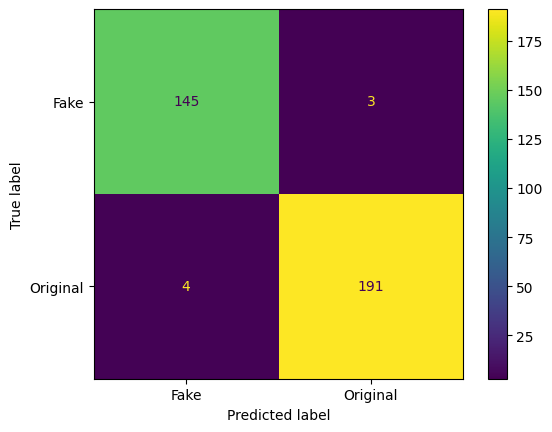

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Fake       0.97      0.98      0.98       148
    Original       0.98      0.98      0.98       195

    accuracy                           0.98       343
   macro avg       0.98      0.98      0.98       343
weighted avg       0.98      0.98      0.98       343



In [32]:
accuracy_score(y_test, y_pred)

0.9795918367346939

In [33]:
dt.feature_importances_

array([0.62095248, 0.21106862, 0.14189251, 0.02608639])

#### Plot the tree

In [35]:
from sklearn.tree import plot_tree

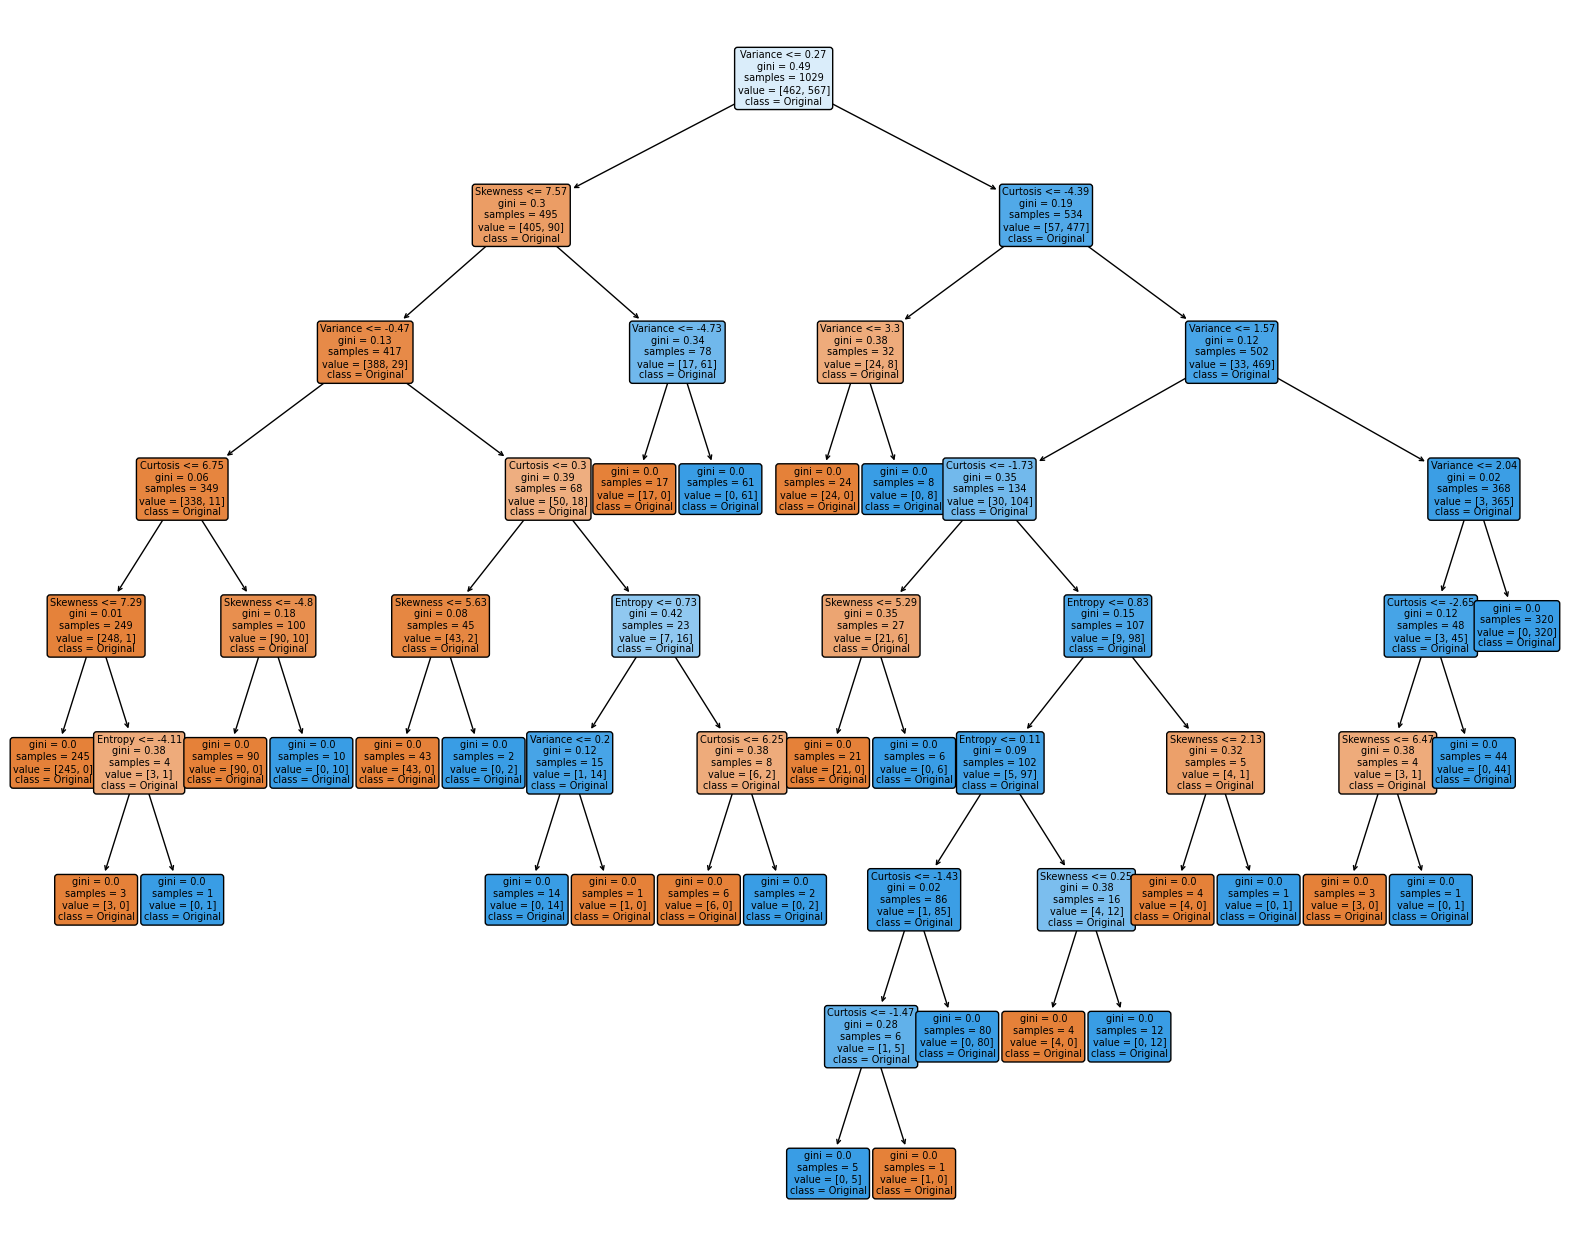

In [39]:
plt.figure(figsize=(20,16))
plot_tree(dt, class_names=y, feature_names=x.columns,filled=True, 
          precision=2, fontsize=7, rounded=True);

In [42]:
df.iloc[12,:]

Variance    1.89930
Skewness    7.66250
Curtosis    0.15394
Entropy    -3.11080
Class       0.00000
Name: 12, dtype: float64

In [43]:
newdf = pd.DataFrame(data=[[5.262, 3.9834, -1.5572, 1.0103], 
                           [-1.3995, -1.9162, 2.5154, 0.59912],
                           [-2.6989, 12.1984, 0.67661, -8.5482]],
                     columns=x.columns)

In [44]:
newdf

,Variance,Skewness,Curtosis,Entropy
0,5.2620,3.9834,-1.55720,1.01030
1,-1.3995,-1.9162,2.51540,0.59912
2,-2.6989,12.1984,0.67661,-8.54820


In [45]:
dt.predict(newdf)

array(['Original', 'Fake', 'Original'], dtype=object)